# Normalization idea and non-negative f

In this notebook, we will attempt to understand when f becomes negative, given an H and g.

The idea is that for some values of g, the optimal solution requires a value in f to become negative.

We will start with a toy example (two dimensional f and g), plot, compute the optimal solution by hand. And attempt to generalize the condition in g for which f becomes negative for any element.

This will help us generalize and come up with a heuristic for normalizing our actual gene expression and chromatin data, to keep f as a positive valued solution. If we are able to do this, we will still need to be mindful of how the normalization will affect downstream analyses.


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [76]:

# Simple 2x2 with easy to compute numbers
# enforce each row must sum to 1
# i.e. each row is the cell's popluation in different portions of the cell cycle

# Have variables for H for derivative calculations
a, b, c, d = 0.25, 0.75, \
             0.75, 0.25
H = np.array([ [a, b],
               [c, d]])

# Our gene expression values
g1 = 2
g2 = 1
g = np.array([[g1],
              [g2]])

# Objective:
#  Minimize with respect to f:
#
#  ||  Hf - g  || (l2 norm)
#
def compute_l2_sq_norm(f1, f2):
    
    f = [f1, f2]
    
    # The squared l2 norm (squared or unsquared won't offect where
    # the solution is)
    l2_squared_norm = (a*f1 + b*f2 - g1)**2 + (c*f1 + d*f2 - g2)**2

    return l2_squared_norm


In [77]:
f1 = np.linspace(-5, 5, 100)
f2 = np.linspace(-5, 5, 100)

F1, F2 = np.meshgrid(f1, f2)
Z = np.zeros_like(F1)

for i in range(Z.shape[0]):
    for j in range(Z.shape[1]):
        Z[i][j] = compute_l2_sq_norm(F1[i][j], F2[i][j])


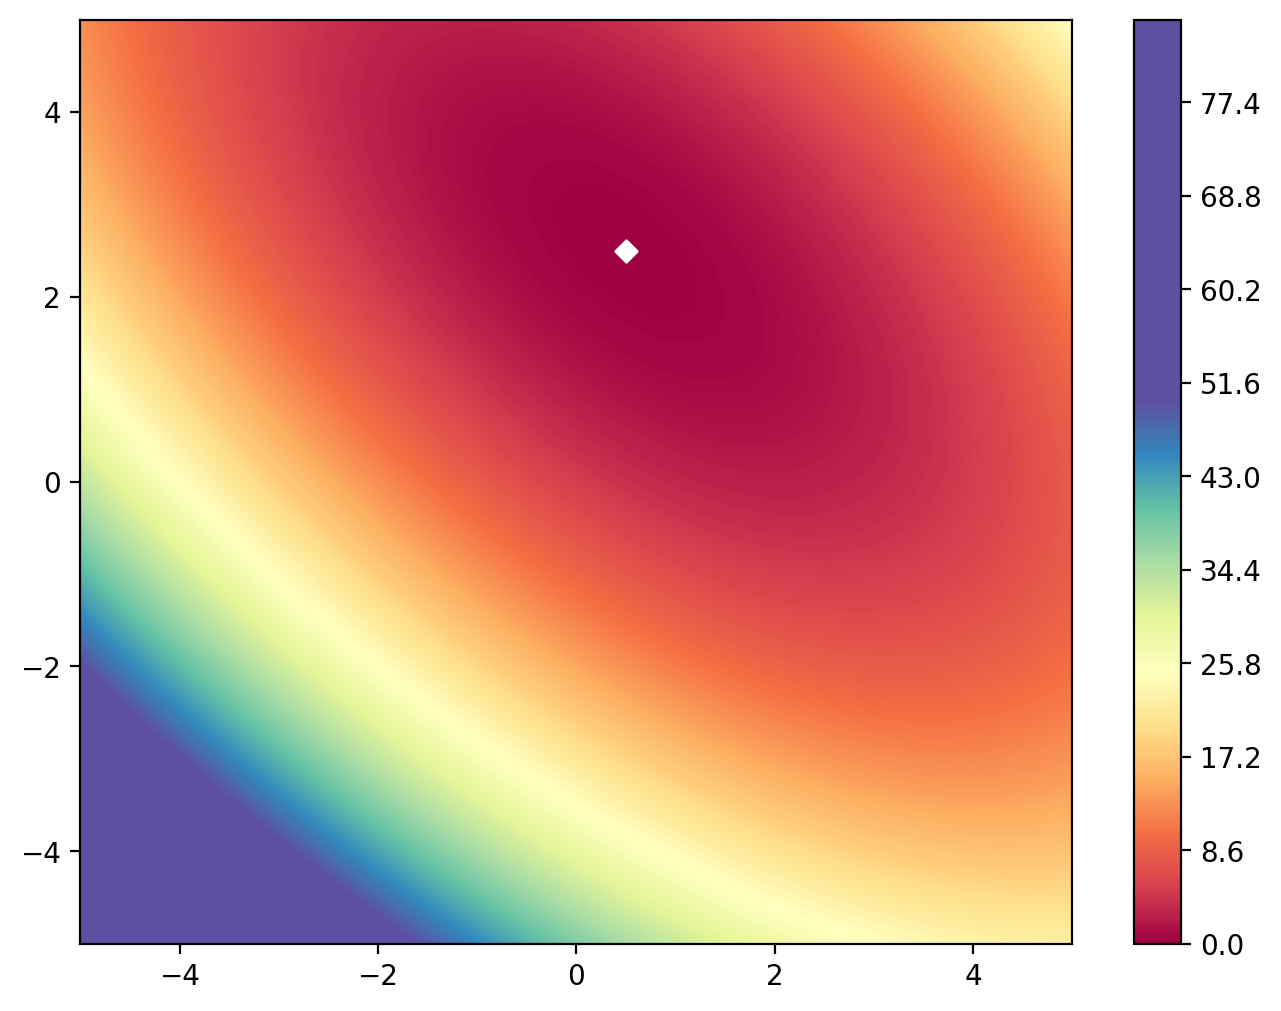

In [93]:
# Create a figure for plotting
fig = plt.figure(figsize=(8, 6))
ax = plt.gca()

# Plot the 3D contour plot
contour = ax.contourf(X, Y, Z, 1000, cmap='Spectral', vmax=50)
plt.colorbar(contour)

plt.scatter(0.5, 5/2, s=30, color='white', marker='D')

In [129]:
u = g1
v = g2

ddx_coeff_y = (2*a*b + 2*c*d)
ddx_coeff_x = (2*a*a+2*c*c)
ddx_intercept = (2*a*u + 2*c*v)

print("Take the partial derivative d/dx")
print(f"\n\t{ddx_coeff_x}x + {ddx_coeff_y}y = {ddx_intercept}")

u = g1
v = g2

ddy_coeff_y = (2*b*b + 2*d*d)
ddy_coeff_x = (2*a*b+2*c*d)
ddy_intercept = (2*b*u + 2*d*v)

print("\nTake the partial derivative d/dy")
print(f"\n\t{ddy_coeff_x}x + {ddy_coeff_y}y = {ddy_intercept}")


Take the partial derivative d/dx

	1.25x + 0.75y = 2.5

Take the partial derivative d/dy

	0.75x + 1.25y = 3.5


In [130]:
# Now that we have a system of equations from the partial derivatives
# We can solve for x and y to determine the values of x and y that minimize the 
# L2 norm

"""
Rearrange so y is on the left, then set equal to one another:

   (ddx_intercept - ddx_coeff_x * x) / ddx_coeff_y
   = (ddy_intercept - ddy_coeff_x * x) / ddy_coeff_y

Solve for x:

ddx_intercept/ddx_coeff_y - ddy_intercept/ddy_coeff_y +
 [(-ddx_coeff_x/ddx_coeff_y) + (ddy_coeff_x/ddy_coeff_y)]*x = 0


-(ddx_intercept/ddx_coeff_y - ddy_intercept/ddy_coeff_y) /
 [(-ddx_coeff_x/ddx_coeff_y) + (ddy_coeff_x/ddy_coeff_y)]
"""

solution_x = -(ddx_intercept/ddx_coeff_y - ddy_intercept/ddy_coeff_y) / \
 ((-ddx_coeff_x/ddx_coeff_y) + (ddy_coeff_x/ddy_coeff_y))

solution_y = (ddx_intercept - ddx_coeff_x*solution_x) / ddx_coeff_y
print(f"\tx = {solution_x:.2f}\n\ty = {solution_y:.2f}")

	x = 0.50
	y = 2.50
